<a href="https://colab.research.google.com/github/Dexter0013/Deepraj-Singha-6th-Sem-CSE-Data-Mining-Assignments/blob/main/2.%20Implementation%20of%20Naive%20Bayes%20classifier%20to%20detect%20Spam%20and%20Not%20Spam%20in%20Emails/Spam_Detection_using_Naive_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Load all the required libraries and perform Preprocessing on uciml/sms-spam-collection-dataset**

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [23]:
# Load the Dataset
import kagglehub
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Dataset downloaded to: /kaggle/input/sms-spam-collection-dataset


**Step 1.1: Load the datset into csv for pre-processing**

In [33]:
df = pd.read_csv("/kaggle/input/sms-spam-collection-dataset/spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']
df['label'] = df['label'].replace('ham', 'not spam')

In [36]:
df

,label,message
0,not spam,"Go until jurong point, crazy.. Available only ..."
1,not spam,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,not spam,U dun say so early hor... U c already then say...
4,not spam,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,not spam,Will Ì_ b going to esplanade fr home?
5569,not spam,"Pity, * was in mood for that. So...any other s..."
5570,not spam,The guy did some bitching but I acted like i'd...


**Step 1.2: Convert labels to binary**

In [50]:
df['label'] = df['label'].map({'spam': 1, 'not spam': 0})

In [52]:
df

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


**Step 1.3: Split into train/test 80/20**

In [58]:
x_train, x_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

In [61]:
x_train

,message
184,Going on nothing great.bye
2171,I wont. So wat's wit the guys
5422,Ok k..sry i knw 2 siva..tats y i askd..
4113,Where are you ? What do you do ? How can you s...
4588,Have you not finished work yet or something?
...,...
1932,Jus finished avatar nigro
5316,Jus finish watching tv... U?
2308,Moby Pub Quiz.Win a å£100 High Street prize if...
1903,Free entry in 2 a weekly comp for a chance to ...


**Step 1.4: Text Vectorization**

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
x_train_vec = vectorizer.fit_transform(x_train)
x_test_vec = vectorizer.transform(x_test)

**Step 2: Model Training**

In [72]:
model = MultinomialNB()
model.fit(x_train_vec, y_train)

MultinomialNB()

**Step 2.1: Model Evaluation**

In [75]:
y_pred = model.predict(x_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.968609865470852

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



**Step 2.2: Evaluation Matrix**

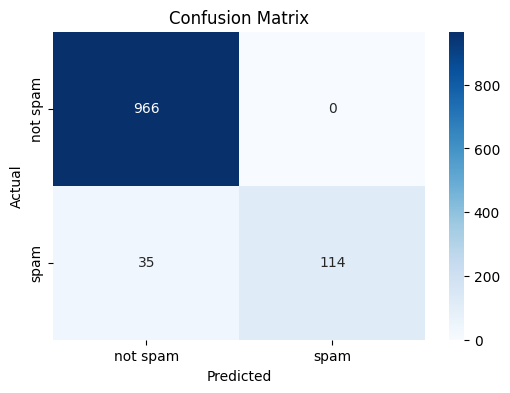

In [96]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['not spam', 'spam'], yticklabels=['not spam', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Step 3: Testing on Custom input**

In [97]:
test_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim.",
    "Hey, are we still meeting for lunch today?","To claim your prize, simply click the link below and complete the short verification form.",
    "URGENT! You have won a 1-week all-expenses-paid cruise to the Bahamas! Call 09061701461 now to claim your prize!",
    "Hey, are you free to grab a coffee tomorrow morning?"
]
test_vec = vectorizer.transform(test_messages)
predictions = model.predict(test_vec)

for msg, pred in zip(test_messages, predictions):
    print(f"Message: {msg}\nPrediction: {'Spam' if pred == 1 else 'Not Spam'}\n")

Message: Congratulations! You've won a $1000 Walmart gift card. Click here to claim.
Prediction: Spam

Message: Hey, are we still meeting for lunch today?
Prediction: Not Spam

Message: To claim your prize, simply click the link below and complete the short verification form.
Prediction: Spam

Message: URGENT! You have won a 1-week all-expenses-paid cruise to the Bahamas! Call 09061701461 now to claim your prize!
Prediction: Spam

Message: Hey, are you free to grab a coffee tomorrow morning?
Prediction: Not Spam



**Saving the model**

In [90]:
import pickle

# Save the model and vectorizer to disk
with open('spam_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

with open('vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(vectorizer, vec_file)

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


**Loading the model**

In [94]:
# Load the model and vectorizer back
with open('spam_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

with open('vectorizer.pkl', 'rb') as vec_file:
    loaded_vectorizer = pickle.load(vec_file)

# Test the loaded model
sample_text = ["You have a new invoice waiting for payment.","Hey, are we still meeting for lunch today?","To claim your prize, simply click the link below and complete the short verification form."]
sample_vec = loaded_vectorizer.transform(sample_text)
prediction = loaded_model.predict(sample_vec)

print(f"Prediction from loaded model: {'Spam' if prediction[2] == 1 else 'Not Spam'}")

Prediction from loaded model: Spam
